In [4]:
import numpy as np
import pandas as pd
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("SOM_data.csv") 

In [6]:
display(df)

,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Status_Partnered,Status_Post-partnered,Status_Single
0,-1.061027,0.25,0.325209,-0.855807,-0.966628,-1.551181,0.312004,1.013201,1.456740,1.434186,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-1.328272,0.25,-0.275447,1.168488,1.034524,1.207501,-0.388707,-1.266582,-0.989483,-1.446495,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.348373,0.25,1.011475,-0.855807,-0.966628,0.209360,-0.809134,0.784427,1.085108,0.474242,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.344179,0.25,-1.278643,1.168488,-0.966628,1.077091,-0.809134,-1.266582,-0.398927,-0.720391,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.076934,1.00,0.333103,1.168488,-0.966628,0.966743,1.573284,0.268942,1.002718,0.426055,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,-0.170210,0.25,0.482324,-0.855807,1.034524,-0.136729,-0.108423,1.076402,1.002718,0.710494,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2236,-1.684598,1.00,0.624467,1.168488,1.034524,1.583685,0.241933,0.756882,-1.436222,-0.462983,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2237,1.076934,0.25,0.266284,-0.855807,-0.966628,0.996838,1.468177,1.218278,1.072087,0.826162,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2238,-1.150108,0.75,0.890875,-0.855807,1.034524,0.991822,-1.439774,0.787110,0.777010,0.817004,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [7]:
df_numeric = df.select_dtypes(include=[np.number])

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_numeric)

In [19]:
# used formula grid = 5 x (square root of n) where n = number of rows
# despite the forumla amounting to 236,64, it's either we pick 15 or 16, depending on which of these 2 values (squared) is closer to 236,64

som_x = 15
som_y = 15

som = MiniSom(
    x=som_x,
    y=som_y,
    input_len=data_scaled.shape[1],
    sigma=1.5,
    learning_rate=0.5,
    random_seed=42
)

In [30]:
som.train_random(data_scaled, num_iteration=2000)

In [41]:
mapped = np.array([som.winner(x) for x in data_scaled])
df['SOM_Cluster'] = mapped[:, 0] * som_y + mapped[:, 1]
display(df.head())

,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Status_Partnered,Status_Post-partnered,Status_Single,SOM_X,SOM_Y,SOM_Cluster
0,-1.061027,0.25,0.325209,-0.855807,-0.966628,-1.551181,0.312004,1.013201,1.456740,1.434186,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0,12,12
1,-1.328272,0.25,-0.275447,1.168488,1.034524,1.207501,-0.388707,-1.266582,-0.989483,-1.446495,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,2,17
2,-0.348373,0.25,1.011475,-0.855807,-0.966628,0.209360,-0.809134,0.784427,1.085108,0.474242,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13,11,206
3,1.344179,0.25,-1.278643,1.168488,-0.966628,1.077091,-0.809134,-1.266582,-0.398927,-0.720391,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,6,2,92
4,1.076934,1.00,0.333103,1.168488,-0.966628,0.966743,1.573284,0.268942,1.002718,0.426055,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13,9,204


In [42]:
df.to_csv("my_dataset.csv", index=False)

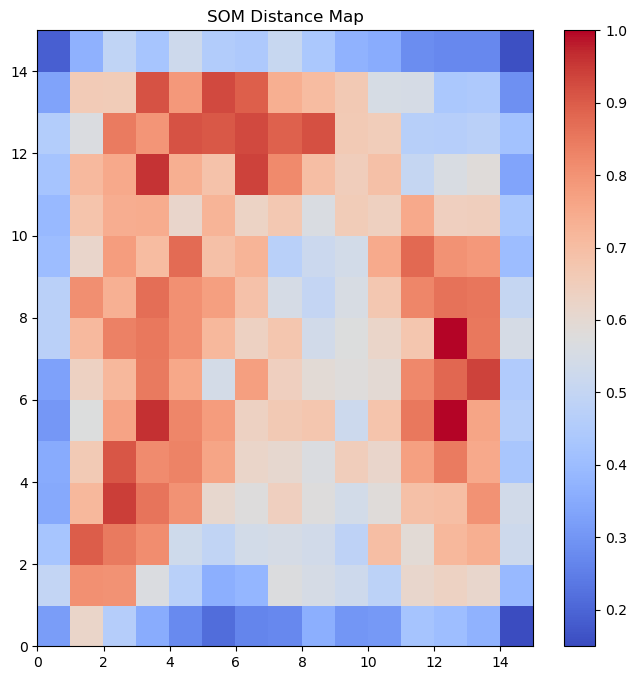

In [31]:
plt.figure(figsize=(8, 8))
plt.title("SOM Distance Map")
plt.pcolor(som.distance_map().T, cmap='coolwarm')
plt.colorbar()
plt.show()

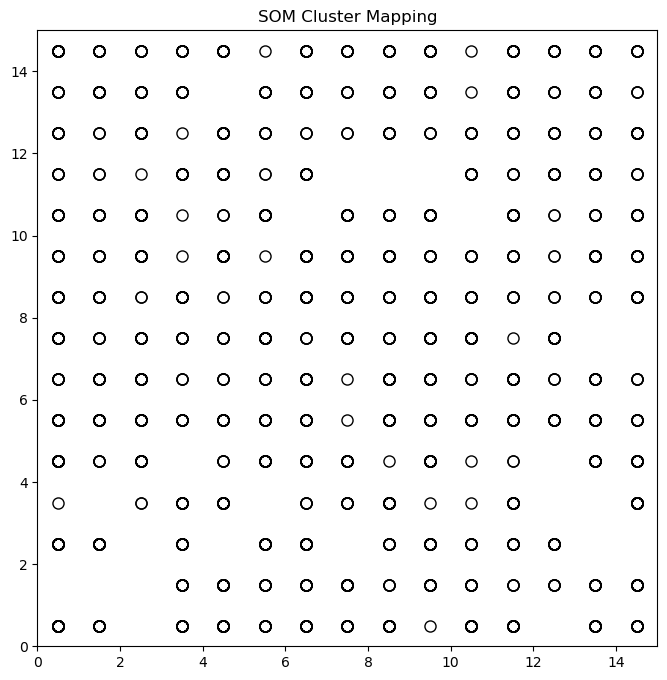

In [33]:
plt.figure(figsize=(8, 8))
for i, x in enumerate(data_scaled):
    w = som.winner(x)
    plt.plot(w[0] + 0.5, w[1] + 0.5, 'o',
             markerfacecolor='None',
             markeredgecolor='black',
             markersize=8)

plt.xlim([0, som_x])
plt.ylim([0, som_y])
plt.title("SOM Cluster Mapping")
plt.show()